<a href="https://colab.research.google.com/github/luciestrada/Proyecto2_Biosenales_LucianaAcevedo_LucianaEstrada/blob/main/Proyecto2_biosenales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Consulta**

**Consultar qué índices del EEG, adicionales a los realizados en el proyecto 1 basados en
densidad espectral de potencia, mejoran la clasificación de estados en BCI. Citar las fuentes**

**Escoger por lo menos tres índices que se puedan implementar en Python, se pueden usar
librerías, explicar la medida y su uso en los datos del proyecto**

En el proyecto 1 utilizamos la densidad espectral de potencia (PSD) calculado con el método de Welch.

1.   **Varianza logarítmica CSP (Patrones Espaciles Comunes)**
Es una técnica de extracción de características ampliamente utilizada en problemas de clasificiación binaria, utiliza un filtrado espacial que transforma señales muticanal de EEG proyectándolas en una matriz de pesos óptimos. El funcionamiento matemático se basa en maximizar la varianza de la señal filtrada para una clase (por ejemplo la imaginación del movimiento de la mano derecha), mientras minimiza la varianza para la otra clase (mano izquierda). Una vez aplicados los filtros espaciales, se calcula la varianza de estas nuevas señales proyectadas y se le aplica una transformación logarítmica (Ramoser et al., 2000).

En otras palabras al aplicar CSP sobre los canales de interés de la corteza motora, el algoritmo aisla matemáticamente las fuentes subyacentes a los electrodos $C3$, $Cz$ y $C4$. Esto incrementa la distancia geométrica entre las clases en el espacio de características, facilitando la tarea del clasificador.

Para cosntruir las caracteríticas Log-Varianza, se calcula la varianza de cada señal z, se normaliza por la varianza total de todas las señales, y se aplica una transformada logarítimca.

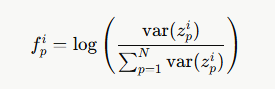




```
Libreria: mne.decoding
```
```

from mne.decoding import CSP
import numpy as np

# Suponiendo que 'epochs_data' tiene la forma (trials, canales, muestras)
# y 'labels' contiene las etiquetas de las clases (0 o 1)
csp = CSP(n_components=4, reg=None, log=True, norm_trace=False)

# Entrena los filtros espaciales y extrae la varianza logarítmica de forma automática
X_csp = csp.fit_transform(epochs_data, labels)
# X_csp tendrá una dimensión de (trials, 4), listo para el clasificador
```

El vector de características final se construye  combinando las log-varianzas de todas las señales.




2. **Parámetros de Hjorth (dominio temporal)**

Son descriptores temporales calculados directamente sobre la señal sin transformada de Fourier, es decir,  aplicados directamente en el dominio del tiempo sobre señales univariadas (canal por canal).  Se basan en los momentos de la densidad espectral de potencia, calculados a través de la varianza de la señal original y sus derivadas sucesivas.

- **Actividad** = Representa la  varianza de de la amplitud de la señal(potencia).

$$\text{Actividad} = \sigma_x^2 = \text{Var}(x(t))$$

- **Movilidad**= Proporciona una estimación de la frecuencia media de la señal. Es la raíz de la varianza de la primera derivada dividida por la varianza de la señal.

$$\text{Movilidad} = \sqrt{\frac{\text{Var}(x'(t))}{\text{Var}(x(t))}}$$

- **Complejidad** = Indica qué tan similar es la señal a una onda senoidal pura. Es la movilidad de la derivada dividida por la movilidad de la señal.


$$\text{Complejidad} = \frac{\text{Movilidad}(x'(t))}{\text{Movilidad}(x(t))} = \sqrt{\frac{\text{Var}(x''(t))/\text{Var}(x'(t))}{\text{Var}(x'(t))/\text{Var}(x(t))}}$$



Durante el estado de reposo, las señales de la corteza motora muestran ondas rítmicas, suaves y sincronizadas (ritmo Mu/Alfa), lo que se traduce en una baja Movilidad y una Complejidad cercana a 1.  En BCI de MI, la complejidad tiende a ser mayor durante la imaginación que durante el movimiento real, , ya que el primero genera una señal más regular por retroalimentación propioceptiva.


```
Libreria: antropy o mne_features.univariate
```
```
import antropy as am
import numpy as np

# Se calcula sobre una matriz 'signal_epoch' de dimensiones (n_channels, n_times)
hjorth_features = []
for channel_data in signal_epoch:
    mobility, complexity = am.hjorth_params(channel_data)
    hjorth_features.extend([mobility, complexity])
# Retorna un vector con los índices de movilidad y complejidad por canal
```
Los parámetros de Hjorth capturan esta transición geométrica instantáneamente en cada época de análisis.  (Hjorth, 1970)

3. **Entropía de Permutación (PE)**

Es una métrica basada en la dinámica no lineal y la teoría de la información que cuantifica la complejidad, el desorden y la impredecibilidad de una serie temporal compleja. Su principal ventaja es que evalúa las relaciones ordinales entre los puntos de la señal, ignorando las amplitudes absolutas del voltaje. Específicamente, la PE mide la regularidad de la señal comparando el orden relativo de sus valores en ventanas deslizantes de longitud $m$ (orden de embedding). Tras determinar el patrón ordinal (permutación) de cada ventana, se calcula la entropía de Shannon de la distribución de dichos patrones mediante la ecuación:


$$PE = -\sum p(\pi) \cdot \log(p(\pi))$$

donde $\pi$ recorre las $m!$ permutaciones posibles. De este modo, una señal completamente regular (como una sinusoide perfecta) exhibe un $PE \approx 0$, mientras que una señal totalmente aleatoria alcanza la PE máxima (Bandt & Pompe, 2002)


Durante tareas de Imaginería Motora (MI), la desincronización cortical incrementa la irregularidad de la señal, elevando consecuentemente la PE.

La Entropía de Permutación actúa como una alternativa radical a la PSD porque es completamente inmune a los artefactos de parpadeo ocular (EOG) de gran amplitud o cambios repentinos de impedancia. Al evaluar las épocas del dataset, la PE cuantificará con alta precisión el incremento del caos combinatorio microestructural de la señal, provocado por la fragmentación del ritmo de reposo durante la activación motora (tanto imaginada como real). *De hecho, la literatura demuestra que la PE discrimina estados de reposo, MI y MR de mejor manera que la PSD en sujetos con baja relación señal-ruido (SNR) (Li et al., 2014)*.




```
Librería: antropy
```
```
import antropy as am

# Se recomienda fijar el orden (dimension) d=3, 4 o 5 y el delay delay=1
# signal_channel es un arreglo unidimensional (n_times,)
perm_entropy = am.permutation_entropy(signal_channel, order=3, delay=1, normalize=True)
```


En el contexto de los datos del proyecto, se aplica CSP de manera binaria por pares de condiciones: MR-D vs MR-I, y IM-D vs IM-I, utilizando los 6 canales seleccionados (C3, C4, FC3, FC4, CP3, CP4). Se seleccionan los primeros y últimos 3 componentes del vector propio (m=3, es decir 6 filtros espaciales), tal como recomienda la literatura. La log-varianza de estos componentes constituye el vector de características que se almacena en el dataframe junto con las métricas del proyecto 1.

**Implementación en Python:** Se puede implementar directamente utilizando la librería especializada en neurotecnología MNE-Python (mne.decoding.CSP) en combinación con scikit-learn.

# **Plan de análisis**

**Con la información recolectada, del entregable 1 y del punto anterior, proponer una
metodología de análisis que permita evidenciar la diferencia en ritmos cerebrales asociados
a las condiciones de: reposo, imaginación de movimiento mano derecha, imaginación de movimiento mano izquierda**



**Etapa 1: Carga y Preprocesamiento de los Datos**
La primera etapa corresponde a la carga y acondicionamiento de las señales bioeléctricas.
El pipeline de preprocesamiento es idéntico al implementado en el Proyecto 1 :

- Filtro Notch: Aplicado a 60 Hz para eliminar la interferencia de la red eléctrica.
- Filtro Pasa-Altas: A 1 Hz para remover la deriva de la línea base y frecuencias ultrabajas.
- Filtro Pasa-Bajas: A 40 Hz para limitar el ancho de banda a las frecuencias de interés cognitivo y descartar ruido muscular de alta frecuencia.
- Re-referenciación: Aplicación de Promedio Común (CAR) para reducir el ruido global de los electrodos y mejorar la Relación Señal-Ruido (SNR).
- Segmentación (Epoching): Extracción de épocas desde −1.0 hasta 4.5 segundos respecto al evento motor (pista visual en $t=0$), fijando la corrección de línea base (baseline) entre −1.0 y 0 segundos. Este procedimiento garantiza que las señales estén limpias y normalizadas antes de extraer características.

----

**Etapa 2: Extracción de Características Multidimensionales**

Se implementará una función unificada extraer_caracteristicas(epochs, canales) que calculará, para cada época y cada canal de interés de la corteza motora primaria (C3, C4, FC3, FC4, CP3, CP4), un conjunto de índices complementarios que cubren cuatro dimensiones independientes de la señal EEG:

- Dimensión Frecuencial (Proyecto 1): Se calcula la Densidad Espectral de Potencia (PSD) por bandas Mu (8–13 Hz) y Beta (13–30 Hz) mediante el método de Welch, el porcentaje de desincronización relacionada con el evento (ERD%), y el índice de lateralidad (LI) -
- Dimensión Espacial (Varianza Logarítmica CSP): Se aplica el algoritmo de Patrones Espaciales Comunes (CSP) de forma binaria directa para maximizar la diferencia entre las dos tareas activas (IM-D vs IM-I), seleccionando $m=3$ filtros extremos del vector propio (6 filtros espaciales en total). La log-varianza de las señales proyectadas constituye el vector de características espaciales, y las épocas de reposo se proyectan sobre este mismo espacio para evaluar su comportamiento basal
- Dimensión Temporal (Parámetros de Hjorth): Se calculan los tres descriptores de Hjorth —actividad, movilidad y complejidad—. Para evitar que la señal pierda poder discriminativo, estos parámetros se calcularán sobre la señal en banda ancha preprocesada (1–40 Hz), capturando los cambios geométricos rápidos inducidos por la desincronización neuronal de manera robusta ante la variabilidad inter-sujeto (Hjorth, 1970).
- Dimensión de Complejidad Dinámica: Se calcula la Entropía de Permutación (PE) con orden $m=4$ (longitud que cumple con la condición de estabilidad $N \gg m!$) y retraso $lag=1$ mediante la librería antropy. La PE cuantifica el grado de desorden en la microestructura temporal de la señal sin asumir estacionariedad, siendo ideal para épocas cortas (Bandt & Pompe, 2002).
----

**Etapa 3: Construcción del Dataframe Unificado**

Una rutina de procesamiento por lotes aplicará la función de extracción sobre todos los archivos de todos los sujetos del dataset. Los resultados se estructurarán y consolidarán en un único DataFrame con las columnas: Sujeto, Condicion (REST, IM-D, IM-I), Canal, Banda, Indice y Valor, permitiendo segmentar y consultar cualquier combinación de variables de forma directa.

---

**Etapa 4: Análisis Descriptivo y Estadístico Inferencial**

Para la visualización de datos se emplearán diagramas de caja (boxplots) y gráficos de violín (violinplots) para comparar las distribuciones entre las tres condiciones, junto con mapas de calor de p-valores para identificar los contrastes estadísticamente relevantes .
Dado que el diseño experimental es de medidas repetidas (los mismos sujetos participan en todas las tareas, generando datos correlacionados ), la selección de la prueba estadística inferencial seguirá un criterio estricto de distribución:

- Se aplicará la prueba de Shapiro-Wilk a cada variable para evaluar la normalidad.
- Si se rechaza la hipótesis de normalidad ($p < 0.05$), se utilizará la Prueba de Friedman (equivalente **no paramétrico** para medidas repetidas) para comparar las 3 condiciones, seguida de comparaciones post-hoc por pares mediante la Prueba de Rangos con Signos de Wilcoxon para muestras relacionadas, aplicando la corrección de Bonferroni ($\alpha_{\text{ajustado}} = 0.05 / 3 = 0.0166$).
- Si los datos no rechazan la normalidad, se empleará un ANOVA de Medidas Repetidas con la prueba post-hoc de Tukey.

---

**Etapa 5: Selección de Características (Feature Selection)**


**Etapa 6: Clasificación y Evaluación de Modelos**



# **Planteamiento de Hipótesis**

1. **Dimensión de Frecuencia (PSD en Banda μ)**

- $H_0$: No existen diferencias significativas en la potencia de la banda μ entre los canales C3 y C4 durante las IM-D.

- $H_1$: Existen diferencias significativas en la potencia de la banda μ entre los canales C3 y C4 durante IM-D.

*Existen diferencias significativas en la potencia de la banda Mu entre C3 y C4 durante IM-D, reflejando el control contralateral esperado.*

2. **Dimensión Temporal (Movilidad de Hjorth)**

- $H_0$: No existen diferencias significativas en el parámetro de Movilidad de Hjorth en el canal C3 al comparar el estado de reposo (REST) frente a IM-D.
- $H_2$: Existen diferencias significativas en el parámetro de Movilidad de Hjorth en el canal C3 al comparar el estado de reposo (REST) frente a IM-D.

*La Movilidad de Hjorth en C3 es significativamente diferente durante IM-D respecto a REST, evidenciando activación del hemisferio contralateral*

3. **Dimensión No-Lineal (Entropía de Permutación)**
- $H_0$: No existen diferencias significativas en la Entropía de Permutación en el canal C4 al comparar el estado de reposo (REST) frente a la imaginación de la mano izquierda (IM-I).
- $H_3$: Existen diferencias significativas en la Entropía de Permutación en el canal C4 al comparar el estado de reposo (REST) frente a la imaginación de la mano izquierda (IM-I).

*Evaluar la Entropía de Permutación en C4 durante la condición de mano izquierda permite ver si el caos de la señal cambia en el lugar correcto del cerebro.*

*La Entropía de Permutación en C4 es significativamente diferente durante IM-I respecto a REST, reflejando mayor complejidad dinámica en el hemisferio contralateral a la mano imaginada*

4. **Dimensión Espacial (Filtro CSP)**
- $H_0$: No existen diferencias significativas en los valores de log-varianza del primer componente espacial (CSP) entre IM-D y e IM-I.
- $H_4$: Existen diferencias significativas en los valores de log-varianza del primer componente espacial (CSP) entre IM-D y e IM-I.

*La log-varianza del primer componente CSP difiere significativamente entre IM-D e IM-I, demostrando que el filtro espacial separa ambas condiciones de lateralidad*

5. **Dimensión de Clasificación (Rendimiento BCI)**
- $H_0$: El accuracy global del clasificador supervisado entrenado con las características avanzadas es igual o menor al nivel de azar teórico del 33.3%.
- $H_5$: El accuracy global del clasificador supervisado entrenado con las características avanzadas es significativamente superior al nivel de azar teórico del 33.3%.




# CÓDIGO

In [1]:
!pip install openneuro-py mne-bids

In [2]:
!pip install -q mne antropy

In [3]:
import os
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import mne
import antropy as ant

from google.colab import drive
from scipy import signal as sci_signal
from scipy.signal import sosfiltfilt, butter
from scipy.integrate import trapezoid
from scipy import stats
from mne.decoding import CSP


In [4]:
drive.mount('/content/drive')

RUTA_DRIVE = '/content/drive/MyDrive/Proyecto_BCI_2026'
os.makedirs(RUTA_DRIVE, exist_ok=True)

SUJETOS = [f'sub-{str(i).zfill(3)}' for i in range(1, 21)] # 20 sujetos
RUNS_DESCARGAR = range(1, 9)
EXTENSIONES    = ['_eeg.set', '_events.tsv', '_channels.tsv', '_eeg.json']
BASE_URL       = "https://openneuro.org/crn/datasets/ds004362/files"

def descargar_archivo(url, destino):
    if os.path.exists(destino) and os.path.getsize(destino) > 0:
        return "ya existe"
    os.makedirs(os.path.dirname(destino), exist_ok=True)
    try:
        urllib.request.urlretrieve(url, destino)
        return "ok"
    except Exception as e:
        return f"error: {e}"

print("Descargando datos...\n")
for sub in SUJETOS:
    print(f"  {sub}...")
    for run in RUNS_DESCARGAR:
        for ext in EXTENSIONES:
            nombre  = f"{sub}_task-motion_run-{run}{ext}"
            url     = f"{BASE_URL}/{sub}:eeg:{nombre}"
            destino = os.path.join(RUTA_DRIVE, sub, 'eeg', nombre)
            estado  = descargar_archivo(url, destino)
            if estado not in ("ya existe", "ok"):
                print(f"    {nombre}: {estado}")
    sets = [f for f in os.listdir(os.path.join(RUTA_DRIVE, sub, 'eeg'))
            if f.endswith('.set')]
    print(f"    {len(sets)} archivos .set")

print("\nDescarga completa.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Descargando datos...

  sub-001...
    8 archivos .set
  sub-002...
    8 archivos .set
  sub-003...
    8 archivos .set
  sub-004...
    8 archivos .set
  sub-005...
    8 archivos .set
  sub-006...
    8 archivos .set
  sub-007...
    8 archivos .set
  sub-008...
    8 archivos .set
  sub-009...
    8 archivos .set
  sub-010...
    8 archivos .set
  sub-011...
    8 archivos .set
  sub-012...
    8 archivos .set
  sub-013...
    8 archivos .set
  sub-014...
    8 archivos .set
  sub-015...
    8 archivos .set
  sub-016...
    8 archivos .set
  sub-017...
    8 archivos .set
  sub-018...
    8 archivos .set
  sub-019...
    8 archivos .set
  sub-020...
    8 archivos .set

Descarga completa.


Cargae de archivos

In [5]:
RUNS_INTERES    = [3, 4, 7, 8]
CANALES_INTERES = ['C3', 'C4', 'Cz', 'Fc3', 'Fc4', 'Cp3', 'Cp4']

datos = {}

for sub in SUJETOS:
    print(f"\nCargando {sub}...")
    datos[sub] = {}

    for run_num in RUNS_INTERES:
        ruta_set = os.path.join(RUTA_DRIVE, sub, 'eeg',
                                f"{sub}_task-motion_run-{run_num}_eeg.set")
        ruta_ev  = os.path.join(RUTA_DRIVE, sub, 'eeg',
                                f"{sub}_task-motion_run-{run_num}_events.tsv")

        if not os.path.exists(ruta_set):
            print(f"  run-{run_num}: no encontrado")
            continue

        raw = mne.io.read_raw_eeglab(ruta_set, preload=True, verbose=False)
        disponibles = [c for c in CANALES_INTERES if c in raw.ch_names]
        raw.pick(disponibles)
        df_ev = pd.read_csv(ruta_ev, sep='\t')

        datos[sub][run_num] = {'raw': raw, 'events': df_ev}
        print(f"  run-{run_num}: OK | canales: {raw.ch_names} | eventos: {len(df_ev)}")

print("\nCarga completa.")


Cargando sub-001...
  run-3: OK | canales: ['C3', 'C4', 'Cz', 'Fc3', 'Fc4', 'Cp3', 'Cp4'] | eventos: 30
  run-4: OK | canales: ['C3', 'C4', 'Cz', 'Fc3', 'Fc4', 'Cp3', 'Cp4'] | eventos: 30
  run-7: OK | canales: ['C3', 'C4', 'Cz', 'Fc3', 'Fc4', 'Cp3', 'Cp4'] | eventos: 30
  run-8: OK | canales: ['C3', 'C4', 'Cz', 'Fc3', 'Fc4', 'Cp3', 'Cp4'] | eventos: 30

Cargando sub-002...
  run-3: OK | canales: ['C3', 'C4', 'Cz', 'Fc3', 'Fc4', 'Cp3', 'Cp4'] | eventos: 30
  run-4: OK | canales: ['C3', 'C4', 'Cz', 'Fc3', 'Fc4', 'Cp3', 'Cp4'] | eventos: 30
  run-7: OK | canales: ['C3', 'C4', 'Cz', 'Fc3', 'Fc4', 'Cp3', 'Cp4'] | eventos: 30
  run-8: OK | canales: ['C3', 'C4', 'Cz', 'Fc3', 'Fc4', 'Cp3', 'Cp4'] | eventos: 30

Cargando sub-003...
  run-3: OK | canales: ['C3', 'C4', 'Cz', 'Fc3', 'Fc4', 'Cp3', 'Cp4'] | eventos: 30
  run-4: OK | canales: ['C3', 'C4', 'Cz', 'Fc3', 'Fc4', 'Cp3', 'Cp4'] | eventos: 30
  run-7: OK | canales: ['C3', 'C4', 'Cz', 'Fc3', 'Fc4', 'Cp3', 'Cp4'] | eventos: 30
  run-8: OK |

Preprocesamiento (idéntico al Proyecto 1)

In [6]:
def preprocesar_raw(raw):
    raw = raw.copy()
    raw.filter(l_freq=1.0, h_freq=None, method='iir',
               iir_params=dict(order=4, ftype='butter'),
               phase='zero', verbose=False)
    raw.filter(l_freq=None, h_freq=40.0, method='iir',
               iir_params=dict(order=4, ftype='butter'),
               phase='zero', verbose=False)
    raw.notch_filter(freqs=60.0, method='iir',
                     iir_params=dict(order=2, ftype='butter'),
                     verbose=False)
    raw.set_eeg_reference('average', projection=False, verbose=False)
    return raw

for sub in SUJETOS:
    for run_num in datos[sub]:
        datos[sub][run_num]['raw'] = preprocesar_raw(datos[sub][run_num]['raw'])
    print(f"{sub}: preprocesado")

print("\nPreprocesamiento completo.")

sub-001: preprocesado
sub-002: preprocesado
sub-003: preprocesado
sub-004: preprocesado
sub-005: preprocesado
sub-006: preprocesado
sub-007: preprocesado
sub-008: preprocesado
sub-009: preprocesado
sub-010: preprocesado
sub-011: preprocesado
sub-012: preprocesado
sub-013: preprocesado
sub-014: preprocesado
sub-015: preprocesado
sub-016: preprocesado
sub-017: preprocesado
sub-018: preprocesado
sub-019: preprocesado
sub-020: preprocesado

Preprocesamiento completo.


Segmentación en épocas (idéntico al Proyecto 1)

In [7]:
T_MIN, T_MAX = -1.0, 4.5
BASELINE     = (-1.0, 0.0)

# Solo IM-D , IM-I Y Reposo( REST)
EVENTOS = {
    'TASK2T2': ('IM-D', 1),
    'TASK2T1': ('IM-I', 2),
    'TASK2T0': ('REST', 3),
    'TASK1T0': ('REST', 3),   # reposo de los runs de MR también sirve
}

CONDS_P2 = ['IM-D', 'IM-I', 'REST']

def segmentar_run(raw, df_events):
    sfreq = raw.info['sfreq']
    df_events['value'] = df_events['value'].astype(str).str.strip()
    df_filt = df_events[df_events['value'].isin(EVENTOS)].copy()
    if df_filt.empty:
        return {}
    samples  = (df_filt['onset'].values * sfreq).astype(int)
    ev_ids   = np.array([EVENTOS[v][1] for v in df_filt['value']])
    ev_array = np.column_stack([samples, np.zeros(len(samples), int), ev_ids])
    ev_dict  = {EVENTOS[v][0]: EVENTOS[v][1] for v in df_filt['value'].unique()}
    epochs   = mne.Epochs(raw, ev_array, event_id=ev_dict,
                          tmin=T_MIN, tmax=T_MAX, baseline=BASELINE,
                          reject=None, preload=True, verbose=False)
    return {cond: epochs[cond] for cond in ev_dict
            if cond in epochs.event_id and len(epochs[cond]) > 0}

epocas = {}
for sub in SUJETOS:
    print(f"\nSegmentando {sub}...")
    acumulado = {c: [] for c in CONDS_P2}
    for run_num, contenido in datos[sub].items():
        for cond, ep in segmentar_run(contenido['raw'], contenido['events']).items():
            if cond in acumulado:
                acumulado[cond].append(ep)
    epocas[sub] = {c: mne.concatenate_epochs(l, verbose=False) if l else None
                   for c, l in acumulado.items()}
    for cond, ep in epocas[sub].items():
        n = len(ep) if ep is not None else 0
        print(f"  {cond}: {n} épocas")

print("\nSegmentación completa.")


Segmentando sub-001...


/tmp/ipykernel_61035/2828833460.py:38: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epocas[sub] = {c: mne.concatenate_epochs(l, verbose=False) if l else None
/tmp/ipykernel_61035/2828833460.py:38: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epocas[sub] = {c: mne.concatenate_epochs(l, verbose=False) if l else None
/tmp/ipykernel_61035/2828833460.py:38: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epocas[sub] = {c: mne.concatenate_epochs(l, verbose=False) if l else None


  IM-D: 14 épocas
  IM-I: 16 épocas
  REST: 56 épocas

Segmentando sub-002...


/tmp/ipykernel_61035/2828833460.py:38: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epocas[sub] = {c: mne.concatenate_epochs(l, verbose=False) if l else None
/tmp/ipykernel_61035/2828833460.py:38: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epocas[sub] = {c: mne.concatenate_epochs(l, verbose=False) if l else None
/tmp/ipykernel_61035/2828833460.py:38: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epocas[sub] = {c: mne.concatenate_epochs(l, verbose=False) if l else None


  IM-D: 14 épocas
  IM-I: 14 épocas
  REST: 56 épocas

Segmentando sub-003...


...

/tmp/ipykernel_61035/2828833460.py:38: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epocas[sub] = {c: mne.concatenate_epochs(l, verbose=False) if l else None
/tmp/ipykernel_61035/2828833460.py:38: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epocas[sub] = {c: mne.concatenate_epochs(l, verbose=False) if l else None
/tmp/ipykernel_61035/2828833460.py:38: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epocas[sub] = {c: mne.concatenate_epochs(l, verbose=False) if l else None
/tmp/ipykernel_61035/2828833460.py:38: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epocas[sub] = {c: mne.concatenate_epochs(l, verbose=False) if l else None
/tmp/ipykernel_61035/2828833460.py:38: RuntimeWarning: Concatenation of Annotations 

  IM-D: 14 épocas
  IM-I: 14 épocas
  REST: 56 épocas

Segmentando sub-018...
  IM-D: 14 épocas
  IM-I: 14 épocas
  REST: 56 épocas

Segmentando sub-019...


/tmp/ipykernel_61035/2828833460.py:38: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epocas[sub] = {c: mne.concatenate_epochs(l, verbose=False) if l else None
/tmp/ipykernel_61035/2828833460.py:38: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epocas[sub] = {c: mne.concatenate_epochs(l, verbose=False) if l else None
/tmp/ipykernel_61035/2828833460.py:38: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epocas[sub] = {c: mne.concatenate_epochs(l, verbose=False) if l else None
/tmp/ipykernel_61035/2828833460.py:38: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epocas[sub] = {c: mne.concatenate_epochs(l, verbose=False) if l else None


  IM-D: 14 épocas
  IM-I: 14 épocas
  REST: 56 épocas

Segmentando sub-020...
  IM-D: 14 épocas
  IM-I: 14 épocas
  REST: 56 épocas

Segmentación completa.


/tmp/ipykernel_61035/2828833460.py:38: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epocas[sub] = {c: mne.concatenate_epochs(l, verbose=False) if l else None
/tmp/ipykernel_61035/2828833460.py:38: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epocas[sub] = {c: mne.concatenate_epochs(l, verbose=False) if l else None
/tmp/ipykernel_61035/2828833460.py:38: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epocas[sub] = {c: mne.concatenate_epochs(l, verbose=False) if l else None


**Funciones de los índices nuevo**

In [8]:

def butter_bandpass(sfreq, fmin, fmax, order=4):
    nyq  = sfreq / 2.0
    low  = max(fmin / nyq, 1e-4)
    high = min(fmax / nyq, 1 - 1e-4)
    return butter(order, [low, high], btype='band', output='sos')

#Actividad, movilidad y complejidad de Hjorth para señal 1D.
def hjorth(signal):
    var_sig = np.var(signal)
    if var_sig == 0:
        return 0.0, 0.0, 0.0
    d1     = np.diff(signal)
    var_d1 = np.var(d1)
    mob    = np.sqrt(var_d1 / var_sig)
    d2     = np.diff(d1)
    var_d2 = np.var(d2)
    mob_d1 = np.sqrt(var_d2 / var_d1) if var_d1 > 0 else 0.0
    comp   = mob_d1 / mob if mob > 0 else 0.0
    return float(var_sig), float(mob), float(comp)

#Entropía de permutación normalizada.
def perm_entropy(signal, order=4, lag=1):
    try:
        return float(ant.perm_entropy(signal, order=order,
                                       delay=lag, normalize=True))
    except Exception:
        return np.nan


print("Funciones de índices nuevos definidas.")

Funciones de índices nuevos definidas.


Función de extracción completa (PSD del proyecto 1 + índices nuevos)

In [9]:
# ============================================================
# BANDAS Y VENTANAS
# H1: psd_mu en C3 y C4
# H2: hjorth_mob en C3
# H3: pe_mu en C4
# H4: CSP_1..6 (se calcula aparte)
# H5: clasificación usa todo lo anterior + erd_mu + LI_mu
# ============================================================

T_BASELINE = (-1.0, 0.0)
T_ACTIVO   = (0.5,  3.5)

#Potencia en banda mu o beta por Welch
def pot_banda(data_1d, fmin, fmax, sfreq):
    n        = len(data_1d)
    nperseg  = min(256, n)
    noverlap = min(128, nperseg // 2)
    freqs, psd = sci_signal.welch(data_1d, fs=sfreq,
                                   nperseg=nperseg, noverlap=noverlap)
    idx = (freqs >= fmin) & (freqs <= fmax)
    return trapezoid(psd[idx], x=freqs[idx])


def calcular_metricas(epoch_data, times, sfreq, ch_names):
    """
    Dimensión frecuencial (Como en el proyecto 1):
        psd_mu_C3, psd_mu_C4       → H1
        erd_mu_C3, erd_mu_C4       → clasificación H5
        LI_mu                      → clasificación H5

    Dimensión temporal :
        hjorth_mob_C3, hjorth_mob_C4   → H2 + clasificación H5
        hjorth_comp_C3, hjorth_comp_C4 → clasificación H5

    Dimensión no lineal :
        pe_mu_C3, pe_mu_C4         → H3 + clasificación H5

    """

    def seg(t_ini, t_fin):
        idx = (times >= t_ini) & (times <= t_fin)
        return epoch_data[:, idx]

    seg_base = seg(*T_BASELINE)
    seg_act  = seg(*T_ACTIVO)

    m = {}

    # Solo C3 y C4
    for canal in ['C3', 'C4']:
        if canal not in ch_names:
            continue
        i = ch_names.index(canal)

        # PSD mu (H1)
        p_mu_base = pot_banda(seg_base[i], 8, 13, sfreq)
        p_mu_act  = pot_banda(seg_act[i],  8, 13, sfreq)
        m[f'psd_mu_{canal}'] = p_mu_act

        # ERD% mu (contexto P1 + clasificación H5)
        m[f'erd_mu_{canal}'] = ((p_mu_act - p_mu_base)
                                 / (p_mu_base + 1e-12)) * 100

        # Hjorth movilidad y complejidad (H2 + clasificación H5)
        sig = seg_act[i]
        _, mob, comp = hjorth(sig)
        m[f'hjorth_mob_{canal}']  = mob
        m[f'hjorth_comp_{canal}'] = comp

        # PE banda mu (H3 + clasificación H5)
        sos      = butter_bandpass(sfreq, 8, 13)
        sig_mu   = sosfiltfilt(sos, sig)
        m[f'pe_mu_{canal}'] = perm_entropy(sig_mu, order=4, lag=1)

    # ── LI mu (clasificación H5) ─────────────────────────────
    if 'C3' in ch_names and 'C4' in ch_names:
        p3 = pot_banda(seg_act[ch_names.index('C3')], 8, 13, sfreq)
        p4 = pot_banda(seg_act[ch_names.index('C4')], 8, 13, sfreq)
        m['LI_mu'] = (p3 - p4) / (p3 + p4 + 1e-12)

    return m

print("Columnas que genera por época:")
cols_esperadas = [
    'psd_mu_C3','psd_mu_C4',
    'erd_mu_C3','erd_mu_C4',
    'hjorth_mob_C3','hjorth_mob_C4',
    'hjorth_comp_C3','hjorth_comp_C4',
    'pe_mu_C3','pe_mu_C4',
    'LI_mu'
]
for c in cols_esperadas:
    print(f"  {c}")
print(f"Total: {len(cols_esperadas)} columnas de métricas + sujeto, condicion, trial")

Columnas que genera por época:
  psd_mu_C3
  psd_mu_C4
  erd_mu_C3
  erd_mu_C4
  hjorth_mob_C3
  hjorth_mob_C4
  hjorth_comp_C3
  hjorth_comp_C4
  pe_mu_C3
  pe_mu_C4
  LI_mu
Total: 11 columnas de métricas + sujeto, condicion, trial


Construcción del dataframe

In [10]:
registros = []

for sub in SUJETOS:
    for cond in CONDS_P2:   # solo REST, IM-D, IM-I
        if cond not in epocas[sub] or epocas[sub][cond] is None:
            continue
        ep       = epocas[sub][cond]
        times    = ep.times
        sfreq    = ep.info['sfreq']
        ch_names = ep.ch_names

        for trial_idx in range(len(ep)):
            try:
                data = ep[trial_idx].get_data(copy=False)[0]
                met  = calcular_metricas(data, times, sfreq, ch_names)
                met['sujeto']    = sub
                met['condicion'] = cond
                met['trial']     = trial_idx
                registros.append(met)
            except Exception as e:
                print(f"  Error {sub} {cond} trial {trial_idx}: {e}")

df_final = pd.DataFrame(registros)

cols_id    = ['sujeto', 'condicion', 'trial']
cols_resto = [c for c in df_final.columns if c not in cols_id]
df_final   = df_final[cols_id + cols_resto]

print(f"DataFrame: {df_final.shape[0]} filas × {df_final.shape[1]} columnas")
print(f"Condiciones presentes: {df_final['condicion'].unique()}")
display(df_final.head())

DataFrame: 1686 filas × 14 columnas
Condiciones presentes: ['IM-D' 'IM-I' 'REST']


,sujeto,condicion,trial,psd_mu_C3,erd_mu_C3,hjorth_mob_C3,hjorth_comp_C3,pe_mu_C3,psd_mu_C4,erd_mu_C4,hjorth_mob_C4,hjorth_comp_C4,pe_mu_C4,LI_mu
0,sub-001,IM-D,0,1.706786e-11,219.966892,0.484726,2.031494,0.524947,1.982175e-11,203.318372,0.526192,1.831450,0.506868,-0.072682
1,sub-001,IM-D,1,8.136195e-12,-76.819757,0.522350,1.825627,0.519479,9.254582e-12,-80.918668,0.551421,1.725091,0.542681,-0.060812
2,sub-001,IM-D,2,8.810503e-12,-7.778278,0.472901,1.988958,0.542701,6.792474e-12,-15.458130,0.494837,1.900205,0.541292,0.121546
3,sub-001,IM-D,3,2.824000e-11,-31.988020,0.498939,1.789190,0.532793,3.089371e-11,-29.559401,0.538134,1.677862,0.527914,-0.044130
4,sub-001,IM-D,4,8.089663e-12,251.832234,0.467444,1.893048,0.528661,9.445443e-12,162.539641,0.497048,1.768546,0.539478,-0.073147


`CSP log-varianza`

CSP se calcula a nivel de sujeto, no de época individual. Solo las condiciones activas, solo para IM-D e IM-I.

In [11]:
#CSP

CANALES_CSP = ['C3', 'C4', 'Fc3', 'Fc4', 'Cp3', 'Cp4']
N_COMP_CSP  = 6

csp_registros = []

for sub in SUJETOS:
    ep_imd = epocas[sub].get('IM-D')
    ep_imi = epocas[sub].get('IM-I')

    if ep_imd is None or ep_imi is None:
        print(f"{sub}: falta IM-D o IM-I, saltando CSP.")
        continue

    chs   = [c for c in CANALES_CSP
             if c in ep_imd.ch_names and c in ep_imi.ch_names]
    X_imd = ep_imd.copy().pick_channels(chs, ordered=True).get_data()
    X_imi = ep_imi.copy().pick_channels(chs, ordered=True).get_data()

    X = np.concatenate([X_imd, X_imi], axis=0)
    y = np.array([0] * len(X_imd) + [1] * len(X_imi))

    csp = CSP(n_components=N_COMP_CSP, reg=None, log=True, norm_trace=False)
    try:
        csp.fit(X, y)
    except Exception as e:
        print(f"{sub}: error CSP: {e}")
        continue

    for ep_data, cond in [(X_imd, 'IM-D'), (X_imi, 'IM-I')]:
        logvar = csp.transform(ep_data)   # (n_epocas, 6)
        for trial_idx in range(len(ep_data)):
            fila = {'sujeto': sub, 'condicion': cond, 'trial': trial_idx}
            for comp in range(N_COMP_CSP):
                fila[f'CSP_{comp+1}'] = float(logvar[trial_idx, comp])
            csp_registros.append(fila)

    print(f"{sub}: CSP calculado ({len(X_imd)} IM-D, {len(X_imi)} IM-I épocas)")

df_csp = pd.DataFrame(csp_registros)

# Merge con df_final
df_final = df_final.merge(df_csp, on=['sujeto', 'condicion', 'trial'], how='left')

print(f"\nDataFrame con CSP: {df_final.shape[0]} filas × {df_final.shape[1]} columnas")
print(f"Columnas CSP: {[c for c in df_final.columns if c.startswith('CSP_')]}")

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Computing rank from data with rank=None
    Using tolerance 4.9e-06 (2.2e-16 eps * 6 dim * 3.6e+09  max singular value)
    Estimated rank (data): 6
    data: rank 6 computed from 6 data channels with 0 projectors
Reducing data rank from 6 -> 6
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
sub-001: CSP calculado (14 IM-D, 16 IM-I épocas)
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Computing rank from data with rank=None
    Using tolerance 2.9e-06 (2.2e-16 eps * 6 dim * 2.2e+09  max singular value)
    Estimated rank (data): 6
    data: rank 6 computed from 6 data channels with 0 projectors
Reducing data rank from 6 -> 6
Estimating class=0 covariance using E

Análisis descriptivo (gráficas) y análisis estadístico (hipótesis).

In [12]:
# Configuración visual
ALPHA  = 0.05
COLORES = {
    'MR-D': '#2196F3', 'MR-I': '#4CAF50',
    'IM-D': '#FF9800', 'IM-I': '#9C27B0',
    'REST': '#9E9E9E'
}
CONDS_ACTIVAS = ['IM-D', 'IM-I', 'REST']


**Análisis descriptivo: Hjorth**

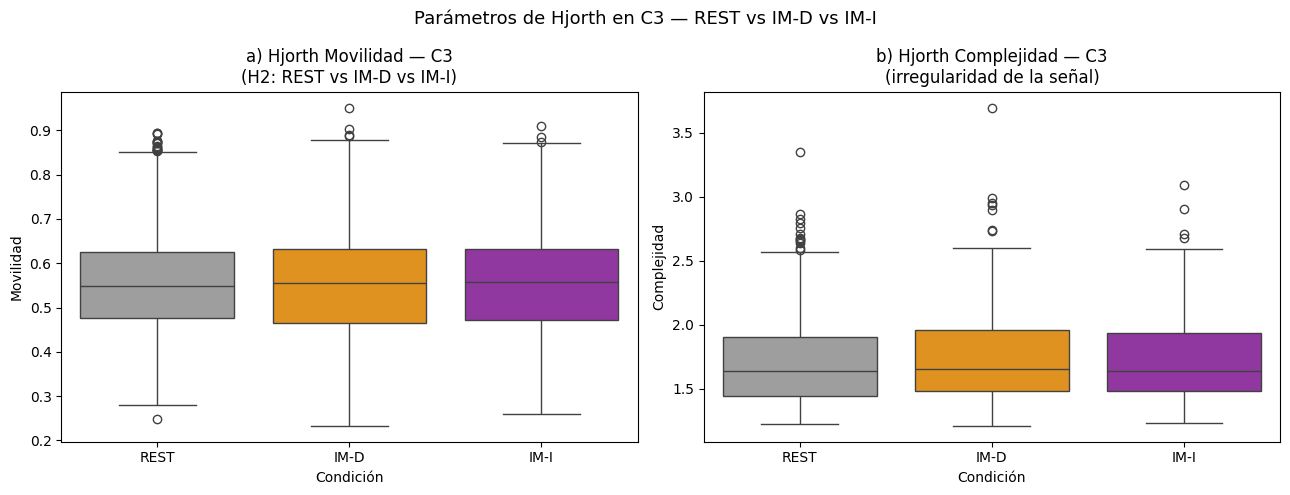

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

df_act = df_final[df_final['condicion'].isin(CONDS_P2)]
orden  = ['REST', 'IM-D', 'IM-I']

# a) Movilidad C3
sns.boxplot(data=df_act, x='condicion', y='hjorth_mob_C3',
            order=orden, hue='condicion', palette=COLORES,
            legend=False, ax=axes[0])
axes[0].set_title('a) Hjorth Movilidad — C3\n(H2: REST vs IM-D vs IM-I)')
axes[0].set_ylabel('Movilidad')
axes[0].set_xlabel('Condición')

# b) Complejidad C3
sns.boxplot(data=df_act, x='condicion', y='hjorth_comp_C3',
            order=orden, hue='condicion', palette=COLORES,
            legend=False, ax=axes[1])
axes[1].set_title('b) Hjorth Complejidad — C3\n(irregularidad de la señal)')
axes[1].set_ylabel('Complejidad')
axes[1].set_xlabel('Condición')

plt.suptitle('Parámetros de Hjorth en C3 — REST vs IM-D vs IM-I', fontsize=13)
plt.tight_layout()
plt.show()

 Análisis descriptivo: Entropía de permutación

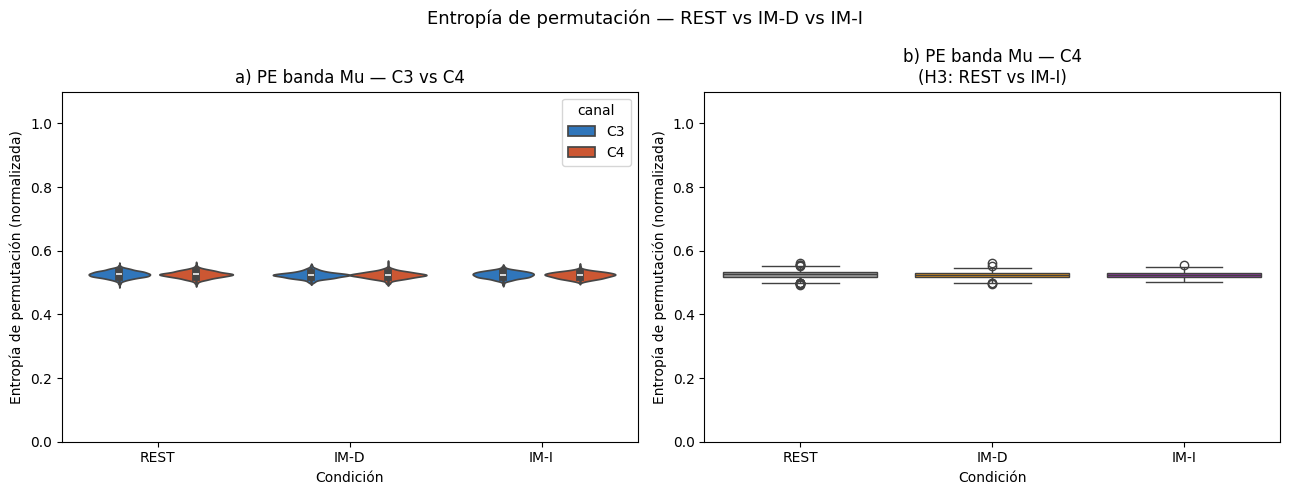

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

df_act = df_final[df_final['condicion'].isin(CONDS_P2)]
orden  = ['REST', 'IM-D', 'IM-I']

# a) PE mu C3 y C4 lado a lado
df_pe_c3 = df_act[['condicion','pe_mu_C3']].copy()
df_pe_c3['canal'] = 'C3'
df_pe_c3 = df_pe_c3.rename(columns={'pe_mu_C3':'PE_mu'})

df_pe_c4 = df_act[['condicion','pe_mu_C4']].copy()
df_pe_c4['canal'] = 'C4'
df_pe_c4 = df_pe_c4.rename(columns={'pe_mu_C4':'PE_mu'})

df_pe_long = pd.concat([df_pe_c3, df_pe_c4], ignore_index=True)

sns.violinplot(data=df_pe_long, x='condicion', y='PE_mu',
               hue='canal', order=orden,
               palette={'C3':'#1976D2','C4':'#E64A19'},
               inner='box', ax=axes[0])
axes[0].set_title('a) PE banda Mu — C3 vs C4')
axes[0].set_ylabel('Entropía de permutación (normalizada)')
axes[0].set_xlabel('Condición')
axes[0].set_ylim(0, 1.1)

# b) PE mu C4 sola
# H3: REST vs IM-I en hemisferio contralateral
sns.boxplot(data=df_act, x='condicion', y='pe_mu_C4',
            order=orden, hue='condicion', palette=COLORES,
            legend=False, ax=axes[1])
axes[1].set_title('b) PE banda Mu — C4\n(H3: REST vs IM-I)')
axes[1].set_ylabel('Entropía de permutación (normalizada)')
axes[1].set_xlabel('Condición')
axes[1].set_ylim(0, 1.1)

plt.suptitle('Entropía de permutación — REST vs IM-D vs IM-I', fontsize=13)
plt.tight_layout()
plt.show()

**Análisis descriptivo: PSD banda Mu en C3 vs C4** --> **Hipótesis H1 (control contralateral)**

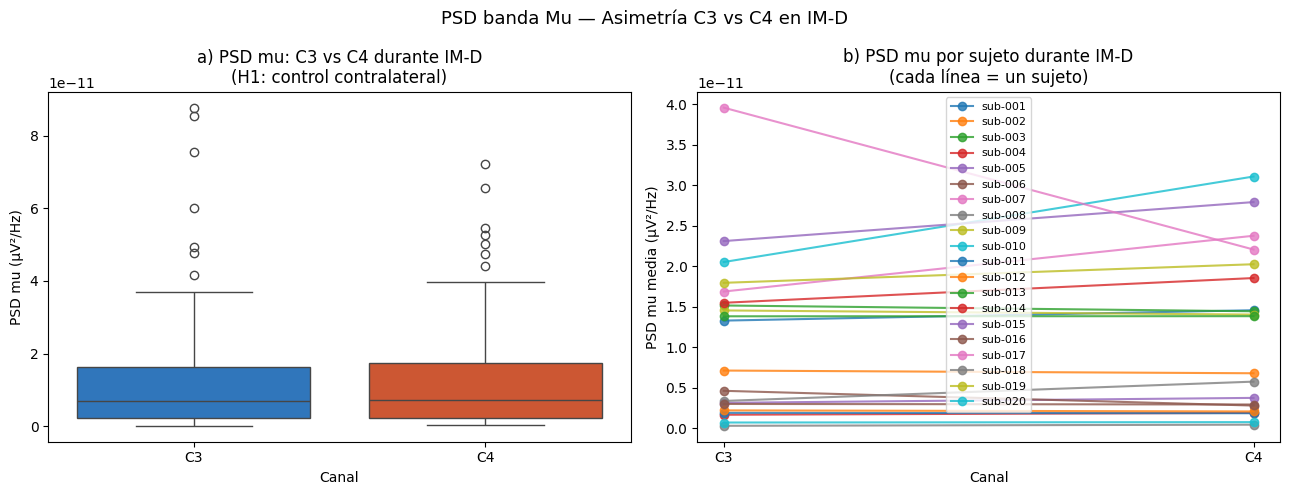

In [15]:
#PSD mu C3 vs C4 dentro de IM-D

df_imd = df_final[df_final['condicion'] == 'IM-D'].copy()

df_psd_c3 = df_imd[['trial', 'sujeto', 'psd_mu_C3']].rename(
    columns={'psd_mu_C3': 'PSD_mu'})
df_psd_c3['canal'] = 'C3'

df_psd_c4 = df_imd[['trial', 'sujeto', 'psd_mu_C4']].rename(
    columns={'psd_mu_C4': 'PSD_mu'})
df_psd_c4['canal'] = 'C4'

df_psd_long = pd.concat([df_psd_c3, df_psd_c4], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=df_psd_long, x='canal', y='PSD_mu',
            hue='canal', palette=['#1976D2', '#E64A19'],
            legend=False, ax=axes[0])
axes[0].set_title('a) PSD mu: C3 vs C4 durante IM-D\n(H1: control contralateral)')
axes[0].set_ylabel('PSD mu (µV²/Hz)')
axes[0].set_xlabel('Canal')

# Scatter: C3 vs C4 por sujeto para ver lateralización individual
medias_sub = df_imd.groupby('sujeto')[['psd_mu_C3', 'psd_mu_C4']].mean()
for sub in medias_sub.index:
    axes[1].plot(['C3', 'C4'],
                 [medias_sub.loc[sub, 'psd_mu_C3'],
                  medias_sub.loc[sub, 'psd_mu_C4']],
                 'o-', alpha=0.8, label=sub)
axes[1].set_title('b) PSD mu por sujeto durante IM-D\n(cada línea = un sujeto)')
axes[1].set_ylabel('PSD mu media (µV²/Hz)')
axes[1].set_xlabel('Canal')
axes[1].legend(fontsize=8)

plt.suptitle('PSD banda Mu — Asimetría C3 vs C4 en IM-D', fontsize=13)
plt.tight_layout()
plt.show()

**Análisis descriptivo: CSP log-varianza --> Hipótesis H4 (CSP_1 discrimina lateralidad)**

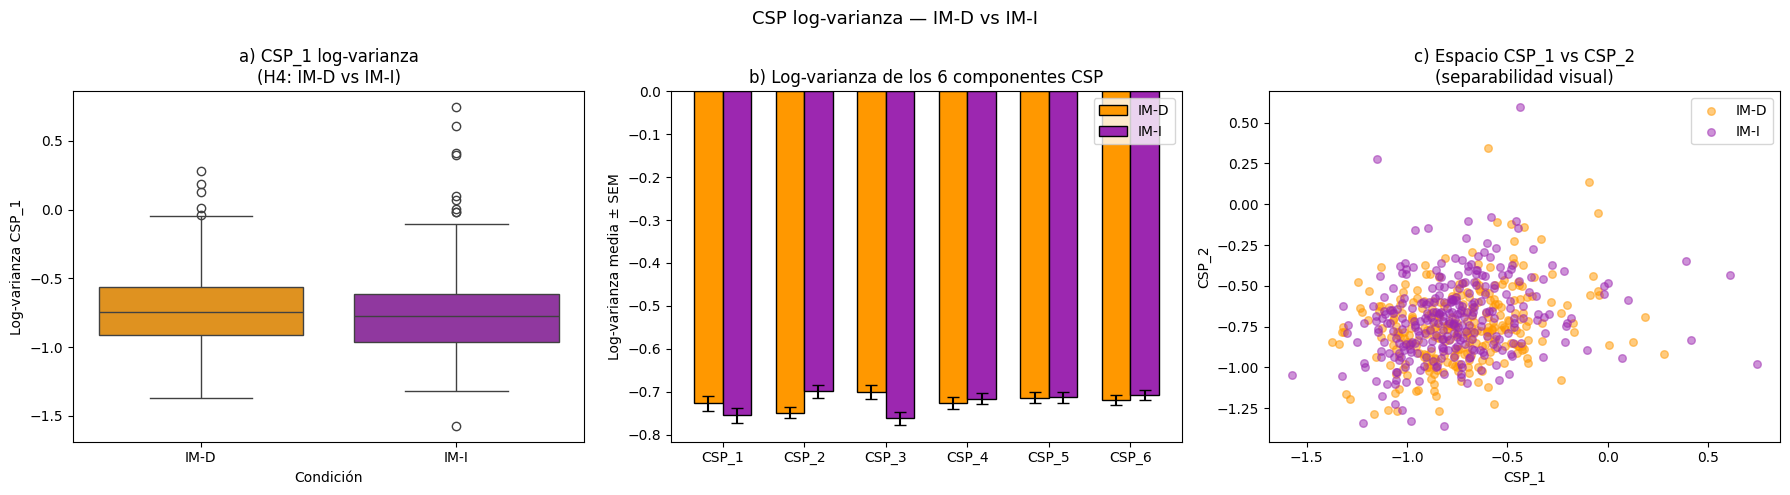

In [16]:
#CSP log-varianza: IM-D vs IM-I


df_csp_plot = df_final[df_final['condicion'].isin(['IM-D', 'IM-I'])].copy()
df_csp_plot = df_csp_plot.dropna(subset=['CSP_1'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# a) Boxplot CSP_1 del componente más discriminativo
sns.boxplot(data=df_csp_plot, x='condicion', y='CSP_1',
            hue='condicion',
            palette={'IM-D': COLORES['IM-D'], 'IM-I': COLORES['IM-I']},
            legend=False, ax=axes[0])
axes[0].set_title('a) CSP_1 log-varianza\n(H4: IM-D vs IM-I)')
axes[0].set_ylabel('Log-varianza CSP_1')
axes[0].set_xlabel('Condición')

# b) Todos los componentes CSP como barplot de medias
csp_cols = [f'CSP_{i}' for i in range(1, 7)
            if f'CSP_{i}' in df_csp_plot.columns]
medias_imd = df_csp_plot[df_csp_plot['condicion'] == 'IM-D'][csp_cols].mean()
medias_imi = df_csp_plot[df_csp_plot['condicion'] == 'IM-I'][csp_cols].mean()
sems_imd   = df_csp_plot[df_csp_plot['condicion'] == 'IM-D'][csp_cols].sem()
sems_imi   = df_csp_plot[df_csp_plot['condicion'] == 'IM-I'][csp_cols].sem()

x = np.arange(len(csp_cols))
w = 0.35
axes[1].bar(x - w/2, medias_imd, w, yerr=sems_imd,
            color=COLORES['IM-D'], capsize=4,
            edgecolor='black', label='IM-D')
axes[1].bar(x + w/2, medias_imi, w, yerr=sems_imi,
            color=COLORES['IM-I'], capsize=4,
            edgecolor='black', label='IM-I')
axes[1].set_xticks(x)
axes[1].set_xticklabels(csp_cols)
axes[1].set_title('b) Log-varianza de los 6 componentes CSP')
axes[1].set_ylabel('Log-varianza media ± SEM')
axes[1].legend()

# c) Scatter CSP_1 vs CSP_2
for cond in ['IM-D', 'IM-I']:
    sub_df = df_csp_plot[df_csp_plot['condicion'] == cond]
    if 'CSP_2' in sub_df.columns:
        axes[2].scatter(sub_df['CSP_1'], sub_df['CSP_2'],
                        color=COLORES[cond], alpha=0.5,
                        label=cond, s=30)
axes[2].set_title('c) Espacio CSP_1 vs CSP_2\n(separabilidad visual)')
axes[2].set_xlabel('CSP_1')
axes[2].set_ylabel('CSP_2')
axes[2].legend()

plt.suptitle('CSP log-varianza — IM-D vs IM-I', fontsize=13)
plt.tight_layout()
plt.show()

**PRUEBAS ESTADISTICAS**


* NORMALIDAD — Kolmogorov-Smirnov con corrección Lilliefors --> Apropiado para n > 50 (con 20 sujetos ~400 valores por grupo)

In [17]:

from scipy.stats import kstest, norm

VARS_STAT = [
    'psd_mu_C3', 'psd_mu_C4',
    'hjorth_mob_C3',
    'pe_mu_C4',
    'CSP_1'
]
VARS_STAT = [v for v in VARS_STAT if v in df_final.columns]

print("=" * 65)
print("KOLMOGOROV-SMIRNOV — NORMALIDAD POR ÍNDICE Y CONDICIÓN")
print(f"(n por grupo estimado: ~{len(df_final) // (len(CONDS_P2) * len(VARS_STAT))})")
print("=" * 65)

ks_rows = []
for var in VARS_STAT:
    for cond in CONDS_P2:
        datos_ks = df_final[df_final['condicion'] == cond][var].dropna()
        n = len(datos_ks)
        if n < 3:
            continue
        # Estandarizar antes del KS
        datos_norm = (datos_ks - datos_ks.mean()) / (datos_ks.std() + 1e-12)
        D, p = kstest(datos_norm, 'norm')
        ks_rows.append({
            'Variable' : var,
            'Condición': cond,
            'n'        : n,
            'D'        : round(D, 4),
            'p'        : round(p, 4),
            'Normal'   : 'Sí' if p > 0.05 else 'No'
        })

df_ks = pd.DataFrame(ks_rows)
display(df_ks)

print("\nDecisión de prueba estadística:")
for var in VARS_STAT:
    sub = df_ks[df_ks['Variable'] == var]
    alguna_no_normal = (sub['Normal'] == 'No').any()
    prueba = "Friedman + Wilcoxon post-hoc (no paramétrica)" \
             if alguna_no_normal else \
             "ANOVA medidas repetidas + Tukey (paramétrica)"
    print(f"  {var:30s} → {prueba}")

KOLMOGOROV-SMIRNOV — NORMALIDAD POR ÍNDICE Y CONDICIÓN
(n por grupo estimado: ~112)


,Variable,Condición,n,D,p,Normal
0,psd_mu_C3,IM-D,281,0.2137,0.0000,No
1,psd_mu_C3,IM-I,285,0.2278,0.0000,No
2,psd_mu_C3,REST,1120,0.2449,0.0000,No
3,psd_mu_C4,IM-D,281,0.2009,0.0000,No
4,psd_mu_C4,IM-I,285,0.2007,0.0000,No
5,psd_mu_C4,REST,1120,0.2437,0.0000,No
6,hjorth_mob_C3,IM-D,281,0.0500,0.4688,Sí
7,hjorth_mob_C3,IM-I,285,0.0491,0.4820,Sí
8,hjorth_mob_C3,REST,1120,0.0388,0.0671,Sí
9,pe_mu_C4,IM-D,281,0.0305,0.9487,Sí



Decisión de prueba estadística:
  psd_mu_C3                      → Friedman + Wilcoxon post-hoc (no paramétrica)
  psd_mu_C4                      → Friedman + Wilcoxon post-hoc (no paramétrica)
  hjorth_mob_C3                  → ANOVA medidas repetidas + Tukey (paramétrica)
  pe_mu_C4                       → ANOVA medidas repetidas + Tukey (paramétrica)
  CSP_1                          → Friedman + Wilcoxon post-hoc (no paramétrica)


Pruebas estadísticas: H1, H2, H3


* Se Aplica Friedman sobre las 3 condiciones para una variable -->  Si es significativo, hace Wilcoxon post-hoc con Bonferroni.

*[ --> si p<0.05 --> Wilcoxon post-hoc con corrección de Bonferroni (3 pares --> α=0.0167)]*
*  Excepción H1: compara C3 vs C4 dentro de UNA condición --> compara dos canales en la misma condición

In [18]:

ALPHA_BON = ALPHA / 3   # 0.0167 para 3 pares

#Friedman sobre las 3 condiciones para una variable
def friedman_y_posthoc(var, label):

    print("=" * 62)
    print(f"{label}")
    print("=" * 62)

    grupos = []
    for cond in CONDS_P2:
        g = df_final[df_final['condicion'] == cond][var].dropna().values
        grupos.append(g)

    n_min = min(len(g) for g in grupos)
    if n_min < 3:
        print("  Datos insuficientes.")
        return None

    grupos_trim = [g[:n_min] for g in grupos]
    chi2, p_fri = stats.friedmanchisquare(*grupos_trim)
    sig = "Se rechaza H₀ ✓" if p_fri < ALPHA else "No se rechaza H₀"
    print(f"Friedman (REST vs IM-D vs IM-I):")
    print(f"  χ² = {chi2:.4f} | p = {p_fri:.4f} | {sig}")

    if p_fri < ALPHA:
        print(f"\nPost-hoc Wilcoxon + Bonferroni (α_ajustado = {ALPHA_BON:.4f}):")
        pares = [('REST','IM-D'), ('REST','IM-I'), ('IM-D','IM-I')]
        for c1, c2 in pares:
            d1 = df_final[df_final['condicion']==c1][var].dropna().values
            d2 = df_final[df_final['condicion']==c2][var].dropna().values
            n  = min(len(d1), len(d2))
            try:
                W, p = stats.wilcoxon(d1[:n], d2[:n])
                sig_par = "SIG ✓" if p < ALPHA_BON else "—"
                print(f"  {c1} vs {c2}: W = {W:.2f}, p = {p:.4f}  {sig_par}")
            except Exception as e:
                print(f"  {c1} vs {c2}: error ({e})")
    else:
        print("  No hay diferencias globales → no se realiza post-hoc.")

    print()
    return p_fri


# ── H1: PSD mu C3 vs C4 dentro de IM-D ──────────────────────
# Wilcoxon pareado directo
print("=" * 62)
print("H1 — PSD mu: C3 vs C4 durante IM-D")
print("     Prueba: Wilcoxon pareado (dos canales, misma condición)")
print("=" * 62)

d_c3 = df_final[df_final['condicion'] == 'IM-D']['psd_mu_C3'].dropna().values
d_c4 = df_final[df_final['condicion'] == 'IM-D']['psd_mu_C4'].dropna().values
n    = min(len(d_c3), len(d_c4))
d_c3, d_c4 = d_c3[:n], d_c4[:n]

W_h1, p_h1 = stats.wilcoxon(d_c3, d_c4)
sig_h1 = "Se rechaza H₀ ✓" if p_h1 < ALPHA else "No se rechaza H₀"
print(f"  W = {W_h1:.2f} | p = {p_h1:.4f} | {sig_h1}\n")


# ── H2: Hjorth Movilidad C3 — REST vs IM-D vs IM-I ──────────
p_h2 = friedman_y_posthoc(
    'hjorth_mob_C3',
    "H2 — Hjorth Movilidad C3: REST vs IM-D vs IM-I\n"
    "     Prueba: Friedman + Wilcoxon post-hoc"
)


# ── H3: PE mu C4 — REST vs IM-D vs IM-I ─────────────────────
col_pe = 'pe_mu_C4'
p_h3 = friedman_y_posthoc(
    col_pe,
    f"H3 — Entropía de permutación {col_pe}: REST vs IM-D vs IM-I\n"
    "     Prueba: Friedman + Wilcoxon post-hoc"
)

# Guardar p-valores para el resumen final
p_h2 = p_h2 if p_h2 is not None else 1.0
p_h3 = p_h3 if p_h3 is not None else 1.0

H1 — PSD mu: C3 vs C4 durante IM-D
     Prueba: Wilcoxon pareado (dos canales, misma condición)
  W = 16536.00 | p = 0.0163 | Se rechaza H₀ ✓

H2 — Hjorth Movilidad C3: REST vs IM-D vs IM-I
     Prueba: Friedman + Wilcoxon post-hoc
Friedman (REST vs IM-D vs IM-I):
  χ² = 14.9964 | p = 0.0006 | Se rechaza H₀ ✓

Post-hoc Wilcoxon + Bonferroni (α_ajustado = 0.0167):
  REST vs IM-D: W = 15466.00, p = 0.0014  SIG ✓
  REST vs IM-I: W = 15364.00, p = 0.0003  SIG ✓
  IM-D vs IM-I: W = 19690.00, p = 0.9296  —

H3 — Entropía de permutación pe_mu_C4: REST vs IM-D vs IM-I
     Prueba: Friedman + Wilcoxon post-hoc
Friedman (REST vs IM-D vs IM-I):
  χ² = 0.2776 | p = 0.8704 | No se rechaza H₀
  No hay diferencias globales → no se realiza post-hoc.



 Pruebas estadísticas: H4

In [19]:

print("=" * 60)
print("H4 — CSP_1 log-varianza: IM-D vs IM-I")
print("=" * 60)

if 'CSP_1' in df_final.columns:
    d_imd_csp = df_final[df_final['condicion']=='IM-D']['CSP_1'].dropna().values
    d_imi_csp = df_final[df_final['condicion']=='IM-I']['CSP_1'].dropna().values
    n         = min(len(d_imd_csp), len(d_imi_csp))

    W_h4, p_h4 = stats.wilcoxon(d_imd_csp[:n], d_imi_csp[:n])
    sig_h4 = "Se rechaza H₀ ✓" if p_h4 < ALPHA else "No se rechaza H₀"
    print(f"Wilcoxon pareado IM-D vs IM-I en CSP_1:")
    print(f"  W = {W_h4:.2f} | p = {p_h4:.4f} | {sig_h4}")

    # Comparar también CSP_2...CSP_6 para ver cuál discrimina más
    print("\nTodos los componentes CSP (IM-D vs IM-I):")
    for comp in range(1, 7):
        col = f'CSP_{comp}'
        if col not in df_final.columns:
            continue
        d1 = df_final[df_final['condicion']=='IM-D'][col].dropna().values
        d2 = df_final[df_final['condicion']=='IM-I'][col].dropna().values
        n  = min(len(d1), len(d2))
        try:
            W, p = stats.wilcoxon(d1[:n], d2[:n])
            sig  = "SIG ✓" if p < ALPHA else "—"
            print(f"  {col}: W={W:.2f}, p={p:.4f}  {sig}")
        except Exception as e:
            print(f"  {col}: error ({e})")
else:
    print("CSP_1 no encontrado en df_final. Verifica que la Celda 9 corrió bien.")

H4 — CSP_1 log-varianza: IM-D vs IM-I
Wilcoxon pareado IM-D vs IM-I en CSP_1:
  W = 17612.00 | p = 0.1069 | No se rechaza H₀

Todos los componentes CSP (IM-D vs IM-I):
  CSP_1: W=17612.00, p=0.1069  —
  CSP_2: W=16958.00, p=0.0364  SIG ✓
  CSP_3: W=15694.00, p=0.0025  SIG ✓
  CSP_4: W=18632.00, p=0.3874  —
  CSP_5: W=19176.00, p=0.6417  —
  CSP_6: W=18613.00, p=0.3798  —


**RESUMEN DE LA ESTADÍSTICA DESCRIPTIVA**

Permite identificar visualmente cuál índice separa mejor las condiciones REST, IM-D, IM-I

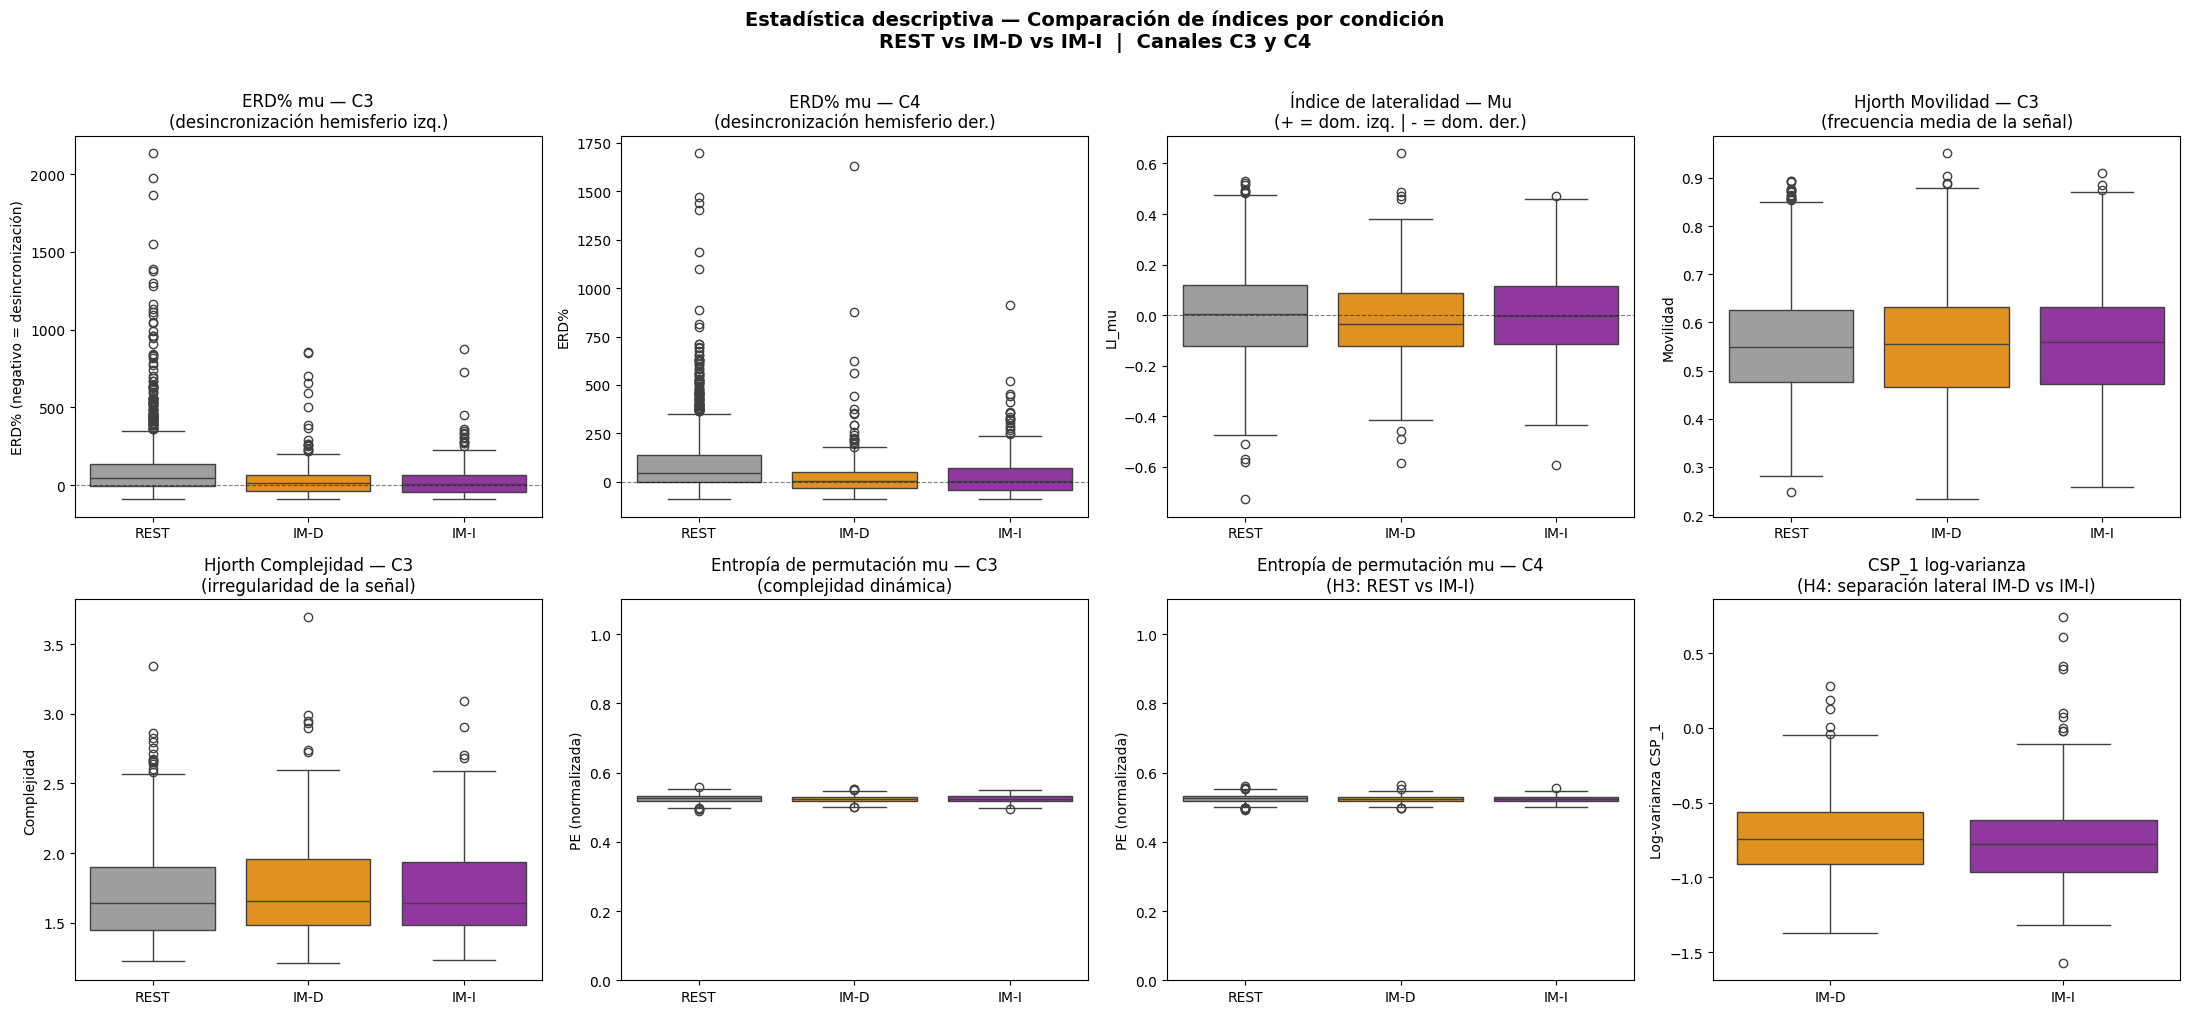

Figura resumen guardada.

Observaciones:
  ERD% mu C3                    : rango de medianas = 40.7531
  Hjorth Movilidad C3           : rango de medianas = 0.0093
  PE mu C4                      : rango de medianas = 0.0017


In [20]:

df_act = df_final[df_final['condicion'].isin(CONDS_P2)].copy()

# Orden fijo de condiciones para todos los gráficos
orden = ['REST', 'IM-D', 'IM-I']
colores_orden = [COLORES[c] for c in orden]

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

# ── Panel 1: ERD% mu en C3 ───────────────────────────────────
sns.boxplot(data=df_act, x='condicion', y='erd_mu_C3',
            order=orden, hue='condicion', palette=COLORES,
            legend=False, ax=axes[0])
axes[0].axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
axes[0].set_title('ERD% mu — C3\n(desincronización hemisferio izq.)')
axes[0].set_ylabel('ERD% (negativo = desincronización)')
axes[0].set_xlabel('')

# ── Panel 2: ERD% mu en C4 ───────────────────────────────────
sns.boxplot(data=df_act, x='condicion', y='erd_mu_C4',
            order=orden, hue='condicion', palette=COLORES,
            legend=False, ax=axes[1])
axes[1].axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
axes[1].set_title('ERD% mu — C4\n(desincronización hemisferio der.)')
axes[1].set_ylabel('ERD%')
axes[1].set_xlabel('')

# ── Panel 3: LI mu ───────────────────────────────────────────
if 'LI_mu' in df_act.columns:
    sns.boxplot(data=df_act, x='condicion', y='LI_mu',
                order=orden, hue='condicion', palette=COLORES,
                legend=False, ax=axes[2])
    axes[2].axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    axes[2].set_title('Índice de lateralidad — Mu\n(+ = dom. izq. | - = dom. der.)')
    axes[2].set_ylabel('LI_mu')
    axes[2].set_xlabel('')

# ── Panel 4: Hjorth Movilidad C3 ─────────────────────────────
sns.boxplot(data=df_act, x='condicion', y='hjorth_mob_C3',
            order=orden, hue='condicion', palette=COLORES,
            legend=False, ax=axes[3])
axes[3].set_title('Hjorth Movilidad — C3\n(frecuencia media de la señal)')
axes[3].set_ylabel('Movilidad')
axes[3].set_xlabel('')

# ── Panel 5: Hjorth Complejidad C3 ───────────────────────────
sns.boxplot(data=df_act, x='condicion', y='hjorth_comp_C3',
            order=orden, hue='condicion', palette=COLORES,
            legend=False, ax=axes[4])
axes[4].set_title('Hjorth Complejidad — C3\n(irregularidad de la señal)')
axes[4].set_ylabel('Complejidad')
axes[4].set_xlabel('')

# ── Panel 6: PE mu C3 ────────────────────────────────────────
if 'pe_mu_C3' in df_act.columns:
    sns.boxplot(data=df_act, x='condicion', y='pe_mu_C3',
                order=orden, hue='condicion', palette=COLORES,
                legend=False, ax=axes[5])
    axes[5].set_ylim(0, 1.1)
    axes[5].set_title('Entropía de permutación mu — C3\n(complejidad dinámica)')
    axes[5].set_ylabel('PE (normalizada)')
    axes[5].set_xlabel('')

# ── Panel 7: PE mu C4 ────────────────────────────────────────
if 'pe_mu_C4' in df_act.columns:
    sns.boxplot(data=df_act, x='condicion', y='pe_mu_C4',
                order=orden, hue='condicion', palette=COLORES,
                legend=False, ax=axes[6])
    axes[6].set_ylim(0, 1.1)
    axes[6].set_title('Entropía de permutación mu — C4\n(H3: REST vs IM-I)')
    axes[6].set_ylabel('PE (normalizada)')
    axes[6].set_xlabel('')

# ── Panel 8: CSP_1 (solo IM-D vs IM-I) ──────────────────────
if 'CSP_1' in df_act.columns:
    df_csp_desc = df_act[df_act['condicion'].isin(['IM-D', 'IM-I'])].copy()
    df_csp_desc = df_csp_desc.dropna(subset=['CSP_1'])
    if len(df_csp_desc) > 0:
        sns.boxplot(data=df_csp_desc, x='condicion', y='CSP_1',
                    order=['IM-D', 'IM-I'],
                    hue='condicion',
                    palette={'IM-D': COLORES['IM-D'], 'IM-I': COLORES['IM-I']},
                    legend=False, ax=axes[7])
        axes[7].set_title('CSP_1 log-varianza\n(H4: separación lateral IM-D vs IM-I)')
        axes[7].set_ylabel('Log-varianza CSP_1')
        axes[7].set_xlabel('')

fig.suptitle(
    'Estadística descriptiva — Comparación de índices por condición\n'
    'REST vs IM-D vs IM-I  |  Canales C3 y C4',
    fontsize=14, fontweight='bold', y=1.01
)

plt.tight_layout()
plt.savefig('descriptivo_resumen_completo.png', dpi=150, bbox_inches='tight')
plt.show()

print("Figura resumen guardada.")
print("\nObservaciones:")
for col, desc in [
    ('erd_mu_C3',    'ERD% mu C3'),
    ('hjorth_mob_C3','Hjorth Movilidad C3'),
    ('pe_mu_C4',     'PE mu C4'),
]:
    if col not in df_act.columns:
        continue
    medias = df_act.groupby('condicion')[col].median()
    mejor_sep = medias.max() - medias.min()
    print(f"  {desc:30s}: rango de medianas = {mejor_sep:.4f}")

------
------
------

 Preparación de features para clasificación

In [21]:

#CLASIFICACIÓN SUPERVISADA

from sklearn.preprocessing     import StandardScaler, LabelEncoder
from sklearn.model_selection   import StratifiedKFold, cross_val_predict
from sklearn.pipeline          import Pipeline
from sklearn.svm               import SVC
from sklearn.metrics           import (confusion_matrix, accuracy_score,
                                        classification_report,
                                        ConfusionMatrixDisplay)
from sklearn.neural_network    import MLPClassifier
from sklearn.feature_selection import SelectKBest, f_classif
import xgboost as xgb
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
warnings.filterwarnings('ignore')

# Usamos los índices que mostraron mayor separación
FEATURES = [
    # H1 — PSD mu (dimensión frecuencial)
    'psd_mu_C3', 'psd_mu_C4',
    # contexto P1
    'erd_mu_C3', 'erd_mu_C4',
    'LI_mu',
    # H2 — Hjorth (dimensión temporal)
    'hjorth_mob_C3', 'hjorth_mob_C4',
    'hjorth_comp_C3', 'hjorth_comp_C4',
    # H3 — PE mu (dimensión no lineal)
    'pe_mu_C3', 'pe_mu_C4',
    # H4 — CSP (dimensión espacial, solo IM-D e IM-I)
    'CSP_1', 'CSP_2', 'CSP_3', 'CSP_4', 'CSP_5', 'CSP_6',
]
FEATURES = [f for f in FEATURES if f in df_final.columns]
print(f"Features para clasificación: {len(FEATURES)}")
print(FEATURES)


# ── Filtrar solo las 3 condiciones del P2 ───────────────────
df_clf = df_final[df_final['condicion'].isin(['REST', 'IM-D', 'IM-I'])].copy()

# Para REST los CSP son NaN → rellenar con 0
# (REST no participó en el ajuste CSP, su log-varianza basal ≈ 0)
csp_cols = [c for c in FEATURES if c.startswith('CSP_')]
df_clf[csp_cols] = df_clf[csp_cols].fillna(0)

# Eliminar filas con NaN en otras columnas
df_clf = df_clf.dropna(subset=FEATURES)

X = df_clf[FEATURES].values
y = LabelEncoder().fit_transform(df_clf['condicion'].values)
# REST=0, IM-D=1, IM-I=2

le = LabelEncoder().fit(df_clf['condicion'].values)
class_names = le.classes_

print(f"Features usados  : {len(FEATURES)}")
print(f"Muestras totales : {len(X)}")
print(f"Clases           : {class_names}")
print(f"Distribución     :")
for nombre, cod in zip(class_names, range(3)):
    print(f"  {nombre}: {(y == cod).sum()} épocas")

Features para clasificación: 17
['psd_mu_C3', 'psd_mu_C4', 'erd_mu_C3', 'erd_mu_C4', 'LI_mu', 'hjorth_mob_C3', 'hjorth_mob_C4', 'hjorth_comp_C3', 'hjorth_comp_C4', 'pe_mu_C3', 'pe_mu_C4', 'CSP_1', 'CSP_2', 'CSP_3', 'CSP_4', 'CSP_5', 'CSP_6']
Features usados  : 17
Muestras totales : 1686
Clases           : ['IM-D' 'IM-I' 'REST']
Distribución     :
  IM-D: 281 épocas
  IM-I: 285 épocas
  REST: 1120 épocas


In [22]:

def plot_confusion(y_true, y_pred, titulo, class_names, ax):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=class_names)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    acc = accuracy_score(y_true, y_pred)
    ax.set_title(f'{titulo}\nAccuracy = {acc:.3f}', fontsize=11)


#   Corre cross_val_predict con k-fold estratificado.
#    Retorna accuracy promedio y predicciones.
def evaluar_modelo(nombre, pipeline, X, y, cv, class_names):

    y_pred = cross_val_predict(pipeline, X, y, cv=cv)
    acc    = accuracy_score(y, y_pred)
    print(f"\n{nombre}")
    print(f"  Accuracy k-fold: {acc:.4f}  ({acc*100:.1f}%)")
    print(classification_report(y, y_pred,
                                  target_names=class_names,
                                  digits=3))
    return acc, y_pred


print("Funciones auxiliares definidas.")

Funciones auxiliares definidas.


 Estrategia k-fold y modelos SVM + XGBoost

Balance de clases por fold:
  Fold 1: test = IM-D:57 | IM-I:57 | REST:224
  Fold 2: test = IM-D:56 | IM-I:57 | REST:224
  Fold 3: test = IM-D:56 | IM-I:57 | REST:224
  Fold 4: test = IM-D:56 | IM-I:57 | REST:224
  Fold 5: test = IM-D:56 | IM-I:57 | REST:224


SVM Lineal
  Accuracy k-fold: 0.8535  (85.3%)
              precision    recall  f1-score   support

        IM-D      0.557     0.594     0.575       281
        IM-I      0.571     0.533     0.552       285
        REST      1.000     1.000     1.000      1120

    accuracy                          0.853      1686
   macro avg      0.709     0.709     0.709      1686
weighted avg      0.854     0.853     0.853      1686


SVM RBF
  Accuracy k-fold: 0.8511  (85.1%)
              precision    recall  f1-score   support

        IM-D      0.559     0.523     0.540       281
        IM-I      0.562     0.589     0.575       285
        REST      0.996     1.000     0.998      1120

    accuracy                          0.851      16

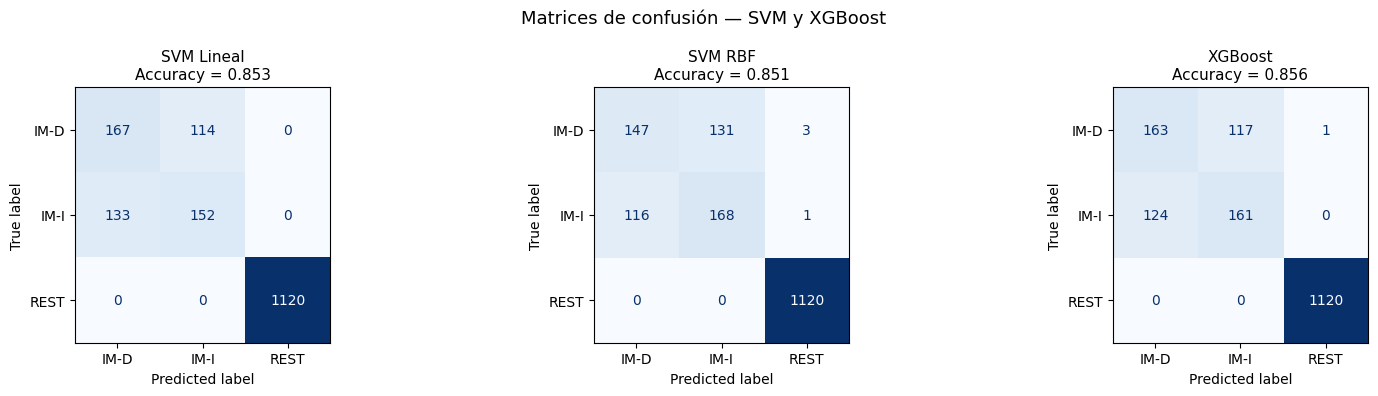

In [23]:
# ============================================================
# K-FOLD ESTRATIFICADO k=5
# Modelos: SVM lineal, SVM RBF, XGBoost
# ============================================================

CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Verificar balance de folds
print("Balance de clases por fold:")
for fold, (train_idx, test_idx) in enumerate(CV.split(X, y)):
    clases_test = [f"{class_names[c]}:{(y[test_idx]==c).sum()}"
                   for c in range(len(class_names))]
    print(f"  Fold {fold+1}: test = {' | '.join(clases_test)}")
print()

resultados = {}   # {nombre: (accuracy, y_pred)}

# ── SVM Lineal ───────────────────────────────────────────────
pipe_svm_lin = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    SVC(kernel='linear', C=1.0,
                   random_state=42, class_weight='balanced'))
])
acc, ypred = evaluar_modelo('SVM Lineal', pipe_svm_lin, X, y, CV, class_names)
resultados['SVM Lineal'] = (acc, ypred)

# ── SVM RBF ──────────────────────────────────────────────────
pipe_svm_rbf = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    SVC(kernel='rbf', C=10.0, gamma='scale',
                   random_state=42, class_weight='balanced'))
])
acc, ypred = evaluar_modelo('SVM RBF', pipe_svm_rbf, X, y, CV, class_names)
resultados['SVM RBF'] = (acc, ypred)

# ── XGBoost ──────────────────────────────────────────────────
pipe_xgb = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    xgb.XGBClassifier(
                   n_estimators=200, max_depth=4,
                   learning_rate=0.05, subsample=0.8,
                   eval_metric='mlogloss',
                   random_state=42, verbosity=0))
])
acc, ypred = evaluar_modelo('XGBoost', pipe_xgb, X, y, CV, class_names)
resultados['XGBoost'] = (acc, ypred)

# ── Matrices de confusión ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (nombre, (acc, ypred)) in zip(axes,
        {k: v for k, v in resultados.items()
         if k in ['SVM Lineal', 'SVM RBF', 'XGBoost']}.items()):
    plot_confusion(y, ypred, nombre, class_names, ax)

plt.suptitle('Matrices de confusión — SVM y XGBoost', fontsize=13)
plt.tight_layout()
plt.show()

**Red neuronal MLP (Perceptrón Multicapa)**

3 capas densas con Dropout

In [24]:
# RED NEURONAL — MLP (Perceptrón Multicapa)

def crear_mlp(n_features, n_clases):
    model = keras.Sequential([
        layers.Input(shape=(n_features,)),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu'),
        layers.Dense(n_clases, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model


# K-fold manual para Keras
scaler_mlp = StandardScaler()
y_pred_mlp = np.zeros(len(y), dtype=int)

for fold, (train_idx, test_idx) in enumerate(CV.split(X, y)):
    X_tr = scaler_mlp.fit_transform(X[train_idx])
    X_te = scaler_mlp.transform(X[test_idx])
    y_tr = y[train_idx]

    model = crear_mlp(X_tr.shape[1], len(class_names))
    model.fit(X_tr, y_tr,
              epochs=80, batch_size=32,
              verbose=0,
              validation_split=0.1)

    probs = model.predict(X_te, verbose=0)
    y_pred_mlp[test_idx] = np.argmax(probs, axis=1)

acc_mlp = accuracy_score(y, y_pred_mlp)
resultados['MLP'] = (acc_mlp, y_pred_mlp)

print("MLP")
print(f"  Accuracy k-fold: {acc_mlp:.4f}  ({acc_mlp*100:.1f}%)")
print(classification_report(y, y_pred_mlp,
                              target_names=class_names, digits=3))

MLP
  Accuracy k-fold: 0.8488  (84.9%)
              precision    recall  f1-score   support

        IM-D      0.550     0.548     0.549       281
        IM-I      0.553     0.551     0.552       285
        REST      0.998     1.000     0.999      1120

    accuracy                          0.849      1686
   macro avg      0.700     0.700     0.700      1686
weighted avg      0.848     0.849     0.848      1686



**Red neuronal Conv1D**

In [25]:
# RED NEURONAL 2 — Conv1D

def crear_conv1d(n_features, n_clases):
    model = keras.Sequential([
        layers.Input(shape=(n_features, 1)),
        layers.Conv1D(filters=32, kernel_size=3,
                      activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv1D(filters=64, kernel_size=3,
                      activation='relu', padding='same'),
        layers.GlobalAveragePooling1D(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(n_clases, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model


scaler_conv = StandardScaler()
y_pred_conv = np.zeros(len(y), dtype=int)

for fold, (train_idx, test_idx) in enumerate(CV.split(X, y)):
    X_tr = scaler_conv.fit_transform(X[train_idx])
    X_te = scaler_conv.transform(X[test_idx])

    # Reshape para Conv1D: (muestras, features, 1)
    X_tr_3d = X_tr.reshape(X_tr.shape[0], X_tr.shape[1], 1)
    X_te_3d = X_te.reshape(X_te.shape[0], X_te.shape[1], 1)

    model = crear_conv1d(X_tr.shape[1], len(class_names))
    model.fit(X_tr_3d, y[train_idx],
              epochs=80, batch_size=32,
              verbose=0,
              validation_split=0.1)

    probs = model.predict(X_te_3d, verbose=0)
    y_pred_conv[test_idx] = np.argmax(probs, axis=1)

acc_conv = accuracy_score(y, y_pred_conv)
resultados['Conv1D'] = (acc_conv, y_pred_conv)

print("Conv1D")
print(f"  Accuracy k-fold: {acc_conv:.4f}  ({acc_conv*100:.1f}%)")
print(classification_report(y, y_pred_conv,
                              target_names=class_names, digits=3))

Conv1D
  Accuracy k-fold: 0.8262  (82.6%)
              precision    recall  f1-score   support

        IM-D      0.475     0.413     0.442       281
        IM-I      0.488     0.551     0.517       285
        REST      1.000     1.000     1.000      1120

    accuracy                          0.826      1686
   macro avg      0.654     0.655     0.653      1686
weighted avg      0.826     0.826     0.825      1686



**Red neuronal EEGNet simplificado**




In [26]:
# RED NEURONAL 3 — EEGNet simplificado

def crear_eegnet_simple(n_features, n_clases):
    inputs = keras.Input(shape=(n_features, 1))

    # Bloque 1: convolución temporal
    x = layers.Conv1D(8, kernel_size=5,
                       padding='same', use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)

    # Bloque 2: convolución depthwise (simula filtros espaciales)
    x = layers.DepthwiseConv1D(kernel_size=3,
                                 padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('elu')(x)
    x = layers.AveragePooling1D(pool_size=2)(x)
    x = layers.Dropout(0.25)(x)

    # Bloque 3: convolución separable
    x = layers.SeparableConv1D(16, kernel_size=3,
                                 padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('elu')(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(n_clases, activation='softmax')(x)

    model = keras.Model(inputs, outputs)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model


scaler_eeg = StandardScaler()
y_pred_eeg = np.zeros(len(y), dtype=int)

for fold, (train_idx, test_idx) in enumerate(CV.split(X, y)):
    X_tr = scaler_eeg.fit_transform(X[train_idx])
    X_te = scaler_eeg.transform(X[test_idx])

    X_tr_3d = X_tr.reshape(X_tr.shape[0], X_tr.shape[1], 1)
    X_te_3d = X_te.reshape(X_te.shape[0], X_te.shape[1], 1)

    model = crear_eegnet_simple(X_tr.shape[1], len(class_names))
    model.fit(X_tr_3d, y[train_idx],
              epochs=80, batch_size=32,
              verbose=0,
              validation_split=0.1)

    probs = model.predict(X_te_3d, verbose=0)
    y_pred_eeg[test_idx] = np.argmax(probs, axis=1)

acc_eeg = accuracy_score(y, y_pred_eeg)
resultados['EEGNet'] = (acc_eeg, y_pred_eeg)

print("EEGNet simplificado")
print(f"  Accuracy k-fold: {acc_eeg:.4f}  ({acc_eeg*100:.1f}%)")
print(classification_report(y, y_pred_eeg,
                              target_names=class_names, digits=3))

EEGNet simplificado
  Accuracy k-fold: 0.8221  (82.2%)
              precision    recall  f1-score   support

        IM-D      0.472     0.530     0.499       281
        IM-I      0.472     0.411     0.439       285
        REST      0.998     1.000     0.999      1120

    accuracy                          0.822      1686
   macro avg      0.647     0.647     0.646      1686
weighted avg      0.821     0.822     0.821      1686



Matrices de confusión redes neuronales

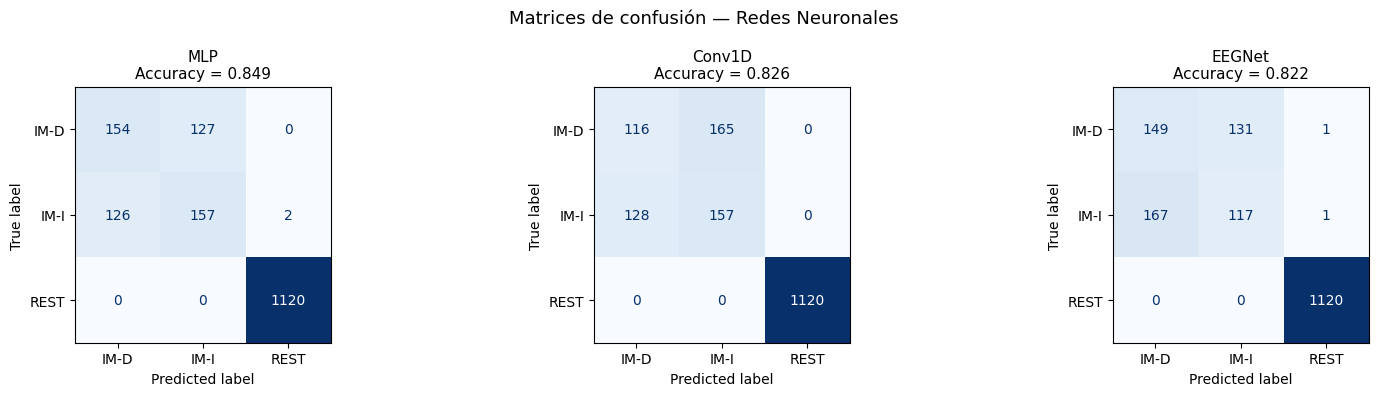

In [27]:
# MATRICES DE CONFUSIÓN — Redes neuronales

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, nombre in zip(axes, ['MLP', 'Conv1D', 'EEGNet']):
    acc, ypred = resultados[nombre]
    plot_confusion(y, ypred, nombre, class_names, ax)

plt.suptitle('Matrices de confusión — Redes Neuronales', fontsize=13)
plt.tight_layout()
plt.show()

 **Comparación final de todos los modelos** :Todos los modelos vs nivel de azar

--> H5: accuracy > 33.3%

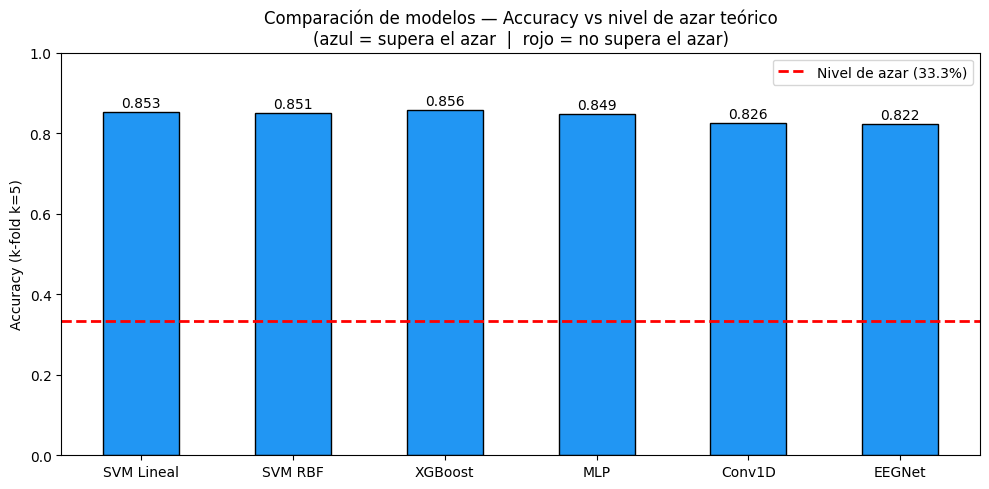


RESUMEN FINAL — H5: accuracy > 33.3%
Modelo            Accuracy    > Azar?
----------------------------------------
SVM Lineal          0.8535       ✓ Sí
SVM RBF             0.8511       ✓ Sí
XGBoost             0.8565       ✓ Sí
MLP                 0.8488       ✓ Sí
Conv1D              0.8262       ✓ Sí
EEGNet              0.8221       ✓ Sí
----------------------------------------
Nivel de azar       0.3333

Mejor modelo: XGBoost (0.8565)
H5: ✓ Se rechaza H₀ — el clasificador supera el azar


In [28]:
# COMPARACIÓN FINAL

UMBRAL_AZAR = 1 / len(class_names)   # 0.333 para 3 clases

nombres  = list(resultados.keys())
accs     = [resultados[n][0] for n in nombres]

fig, ax = plt.subplots(figsize=(10, 5))
colores_bar = ['#2196F3' if a > UMBRAL_AZAR else '#EF5350' for a in accs]
bars = ax.bar(nombres, accs, color=colores_bar,
               edgecolor='black', width=0.5)

# Línea de azar
ax.axhline(UMBRAL_AZAR, color='red', linestyle='--',
            linewidth=2, label=f'Nivel de azar ({UMBRAL_AZAR:.1%})')

# Etiquetas de valor
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f'{acc:.3f}', ha='center', va='bottom', fontsize=10)

ax.set_ylim(0, 1.0)
ax.set_ylabel('Accuracy (k-fold k=5)')
ax.set_title('Comparación de modelos — Accuracy vs nivel de azar teórico\n'
             '(azul = supera el azar  |  rojo = no supera el azar)', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

# ── Resumen en tabla ─────────────────────────────────────────
print("\n" + "=" * 55)
print("RESUMEN FINAL — H5: accuracy > 33.3%")
print("=" * 55)
print(f"{'Modelo':<15} {'Accuracy':>10} {'> Azar?':>10}")
print("-" * 40)
for nombre, acc in zip(nombres, accs):
    supera = "✓ Sí" if acc > UMBRAL_AZAR else "✗ No"
    print(f"{nombre:<15} {acc:>10.4f} {supera:>10}")
print("-" * 40)
print(f"{'Nivel de azar':<15} {UMBRAL_AZAR:>10.4f}")
print("=" * 55)

mejor = nombres[np.argmax(accs)]
print(f"\nMejor modelo: {mejor} ({max(accs):.4f})")
print(f"H5: {'✓ Se rechaza H₀ — el clasificador supera el azar' if max(accs) > UMBRAL_AZAR else '✗ No se rechaza H₀'}")

# **REFERENCIAS**

1. Ramoser, H., Muller-Gerking, J., & Pfurtscheller, G. (2000). Optimal spatial filtering of single trial EEG during imagined hand movement. IEEE Transactions on Rehabilitation Engineering, 8(4), 441–446. https://doi.org/10.1109/86.895946

2. Hjorth, B. (1970). EEG analysis based on time domain properties. Electroencephalography And Clinical Neurophysiology, 29(3), 306-310. https://doi.org/10.1016/0013-4694(70)90143-4

2. Rahman, M. K. M., & Joadder, M. A. M. (2020). A space-frequency localized approach of spatial filtering for motor imagery classification. Health information science and systems, 8(1), 15. https://doi.org/10.1007/s13755-020-00106-8

4. Bandt, C., & Pompe, B. (2002). Permutation Entropy: A Natural Complexity Measure for Time Series. Physical Review Letters, 88(17), 174102. https://doi.org/10.1103/physrevlett.88.174102

4. Li, J., Yan, J., Liu, X., & Ouyang, G. (2014). Using Permutation Entropy to Measure the Changes in EEG Signals During Absence Seizures. Entropy, 16(6), 3049-3061. https://doi.org/10.3390/e16063049

5.
